In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score
from sklearn.preprocessing import StandardScaler


In [22]:
df = pd.read_csv('height-weight.csv')
df

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160
5,78,162
6,80,163
7,90,175
8,95,182
9,78,170


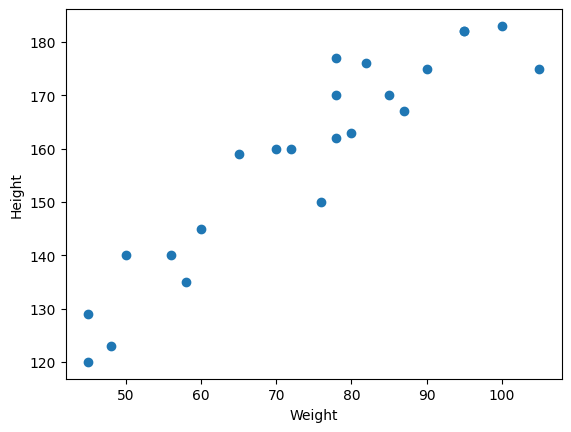

In [23]:
# scatter plot
plt.scatter(df['Weight'], df['Height'])
plt.xlabel('Weight')
plt.ylabel('Height')
plt.show()

In [24]:
# correlation
df.corr()

,Weight,Height
Weight,1.000000,0.931142
Height,0.931142,1.000000


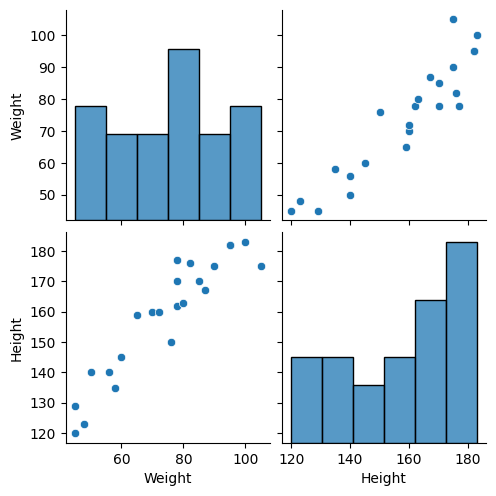

In [25]:
sns.pairplot(df)

In [26]:
X = df[["Weight"]] # independent features should be a dataframe or a 2D array
Y = df["Height"] # this can be a series or a 1D array

In [27]:
type(X)

pandas.core.frame.DataFrame

In [38]:
# train test split
X_train,X_test,y_train,y_test = train_test_split(X,Y,test_size=0.2,random_state=42)

the random state parameter ensures that we dont get a randomized dataset everytime . So if we are performing an experiment , we can simulate the datasets equally for each new experiment

### STANDARDIZATION

Here the features have different units . This affects the linear regression model as linear regression we use gradient descent , if we are taking a larger value this descent will take time . So for optimization we convert into a standard format using
#### Z - Score
whose formula is :
Z - score = xi - mue / sigma

In [39]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)

In [40]:
X_test = scaler.transform(X_test)

### LINEAR REGRESSION

Now after standardization we are going to apply the algorithm on this dataset using the sklearn library .

In [41]:
linereg = LinearRegression(n_jobs=-1)
linereg.fit(X_train,y_train)

LinearRegression(n_jobs=-1)

In [42]:
print(linereg.coef_,linereg.intercept_)

[17.03440872] 157.5


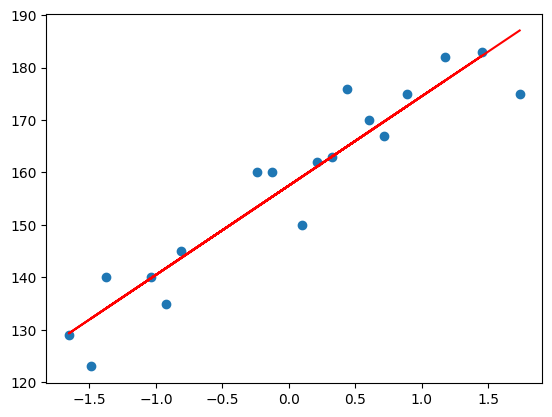

In [43]:
plt.scatter(X_train,y_train)
plt.plot(X_train,linereg.predict(X_train),color='red')

### PREDICTION FOR THE TEST

##### preedicted_height_output = y_intercept + coefficient(weights)
##### y_pred_test = 157.5 + 17.03440872(X_test_i)

In [44]:
y_pred = linereg.predict(X_test)

## PERFORMANCE METRICS

1. MSE ( Mean Square Error )
2. MAE ( Mean Absolute Error )
3. RMSE ( Root Mean Square Error )
4. R^2 = 1 - SSR/SST , SSR = Sum of Square of Residuals , SST = Total Sum of Squares
5. Adjusted R^2

In [51]:
mse = mean_squared_error(y_test,y_pred)
mae = mean_absolute_error(y_test,y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test,y_pred)
adjusted_r2 = 1 - (1-r2)*(len(y_test)-1)/(len(y_test)-X_test.shape[1]-1)
print(mse,mae,rmse,r2,adjusted_r2)

109.77592599051654 9.822657814519227 10.477400726827076 0.7769869860423441 0.7026493147231254


### OLS REGRESSION MODEL

In [55]:
model = sm.OLS(y_train,X_train).fit()
pred = model.predict(X_test)
pred

array([  3.58467086,   3.58467086, -28.1958439 ,  19.95645118,
        -8.93492586])

In [56]:
print(model.summary())

                                 OLS Regression Results                                
Dep. Variable:                 Height   R-squared (uncentered):                   0.012
Model:                            OLS   Adj. R-squared (uncentered):             -0.047
Method:                 Least Squares   F-statistic:                             0.1986
Date:                Thu, 11 Sep 2025   Prob (F-statistic):                       0.661
Time:                        00:31:47   Log-Likelihood:                         -116.62
No. Observations:                  18   AIC:                                      235.2
Df Residuals:                      17   BIC:                                      236.1
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

/Users/kalp/PycharmProjects/Machine_learning/.venv/lib/python3.9/site-packages/scipy/stats/_axis_nan_policy.py:531: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=18
  res = hypotest_fun_out(*samples, **kwds)


### PREDICTION FOR NEW DATA

In [58]:
linereg.predict(scaler.transform([[72]]))

/Users/kalp/PycharmProjects/Machine_learning/.venv/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([155.30639545])